In [1]:
import seaborn as sns
print(sns.__version__)

Matplotlib is building the font cache; this may take a moment.


0.13.2


In [10]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_raw_data

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.load_data import load_raw_data

#display all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)



In [11]:
df = load_raw_data()
df.head()

Data loaded successfully.
Rows: 6362620
Columns: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.6400,C1231006815,170136.0000,160296.3600,M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,1864.2800,C1666544295,21249.0000,19384.7200,M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,21182.0000,0.0000,1,0
4,1,PAYMENT,11668.1400,C2048537720,41554.0000,29885.8600,M1230701703,0.0000,0.0000,0,0


In [13]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [14]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 6362620
Columns: 11


In [15]:
df.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [18]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": missing_percentage
}).sort_values(by="missing_count", ascending=False)

missing_report

,missing_count,missing_percentage
step,0,0.0000
type,0,0.0000
amount,0,0.0000
nameOrig,0,0.0000
oldbalanceOrg,0,0.0000
newbalanceOrig,0,0.0000
nameDest,0,0.0000
oldbalanceDest,0,0.0000
newbalanceDest,0,0.0000
isFraud,0,0.0000


In [19]:
duplicate_count = df.duplicated().sum()
duplicate_count
print(f"Duplicate rows: {duplicate_count}")
print(f"Duplicate percentage: {(duplicate_count / len(df)) * 100:.4f}%")

Duplicate rows: 0
Duplicate percentage: 0.0000%


In [21]:
target_report = pd.DataFrame({
    "count": df["isFraud"].value_counts(),
    "percentage": df["isFraud"].value_counts(normalize=True) * 100
})

target_report

,count,percentage
isFraud,,
0,6354407,99.8709
1,8213,0.1291


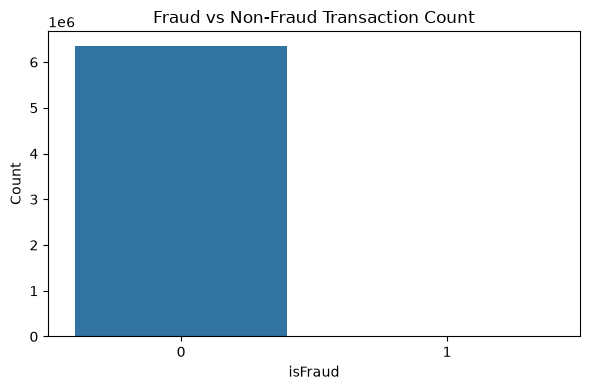

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="isFraud")
plt.title("Fraud vs Non-Fraud Transaction Count")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png")
plt.show()

In [23]:
non_fraud_count = df[df["isFraud"] == 0].shape[0]
fraud_count = df[df["isFraud"] == 1].shape[0]

imbalance_ratio = non_fraud_count / fraud_count

print(f"Non-fraud transactions: {non_fraud_count}")
print(f"Fraud transactions: {fraud_count}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Non-fraud transactions: 6354407
Fraud transactions: 8213
Imbalance ratio: 773.70:1


In [24]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [25]:
df["type"].value_counts(normalize=True) * 100

type
CASH_OUT   35.1663
PAYMENT    33.8146
CASH_IN    21.9923
TRANSFER    8.3756
DEBIT       0.6512
Name: proportion, dtype: float64

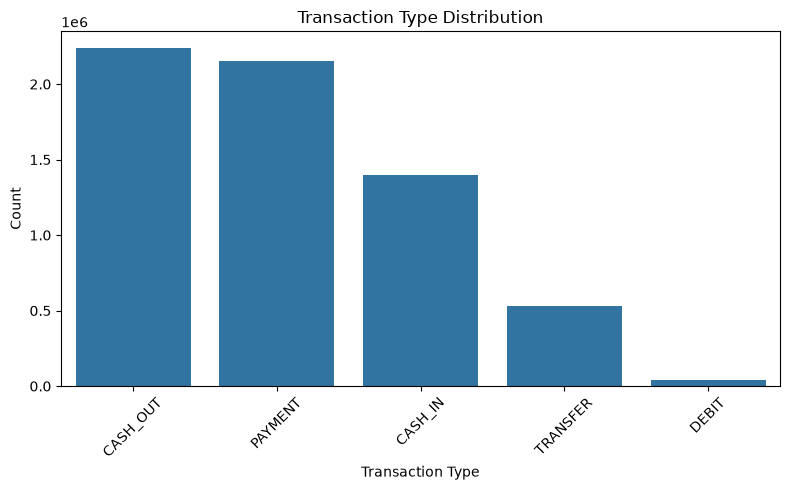

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "transaction_type_distribution.png")
plt.show()

In [27]:
fraud_by_type = df.groupby("type")["isFraud"].agg(["count", "sum", "mean"])
fraud_by_type = fraud_by_type.rename(columns={
    "count": "total_transactions",
    "sum": "fraud_transactions",
    "mean": "fraud_rate"
})

fraud_by_type["fraud_rate_percentage"] = fraud_by_type["fraud_rate"] * 100
fraud_by_type.sort_values(by="fraud_transactions", ascending=False)

,total_transactions,fraud_transactions,fraud_rate,fraud_rate_percentage
type,,,,
CASH_OUT,2237500,4116,0.0018,0.1840
TRANSFER,532909,4097,0.0077,0.7688
CASH_IN,1399284,0,0.0000,0.0000
DEBIT,41432,0,0.0000,0.0000
PAYMENT,2151495,0,0.0000,0.0000


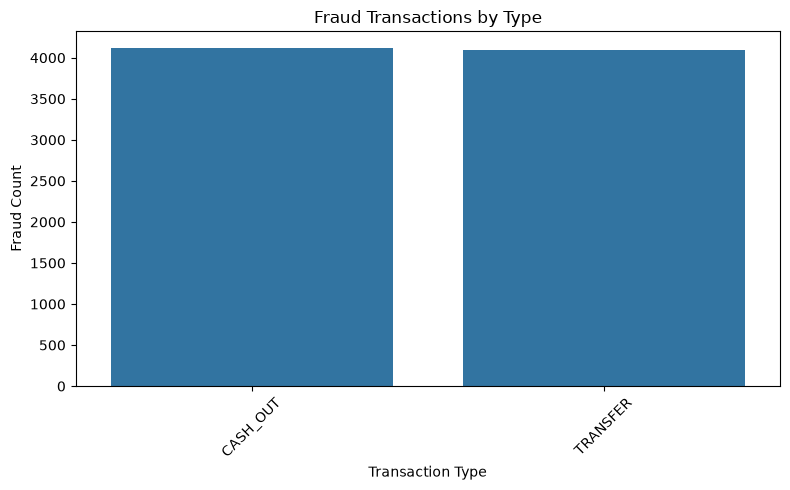

In [28]:
fraud_counts_by_type = df[df["isFraud"] == 1]["type"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=fraud_counts_by_type.index, y=fraud_counts_by_type.values)
plt.title("Fraud Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fraud_by_transaction_type.png")
plt.show()

In [29]:
df["amount"].describe()

count    6362620.0000
mean      179861.9035
std       603858.2315
min            0.0000
25%        13389.5700
50%        74871.9400
75%       208721.4775
max     92445516.6400
Name: amount, dtype: float64

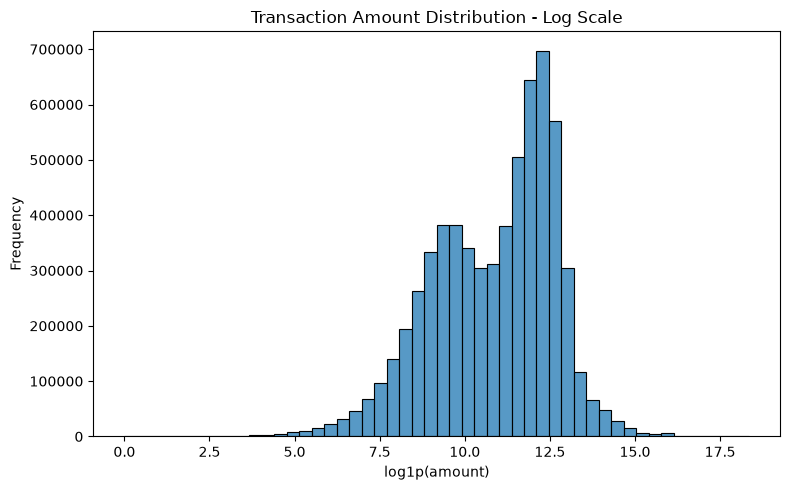

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df["amount"]), bins=50)
plt.title("Transaction Amount Distribution - Log Scale")
plt.xlabel("log1p(amount)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "amount_distribution_log.png")
plt.show()

In [31]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0000,178197.0417,596236.9813,0.0100,13368.3950,74684.7200,208364.7600,92445516.6400
1,8213.0000,1467967.2991,2404252.9472,0.0000,127091.3300,441423.4400,1517771.4800,10000000.0000


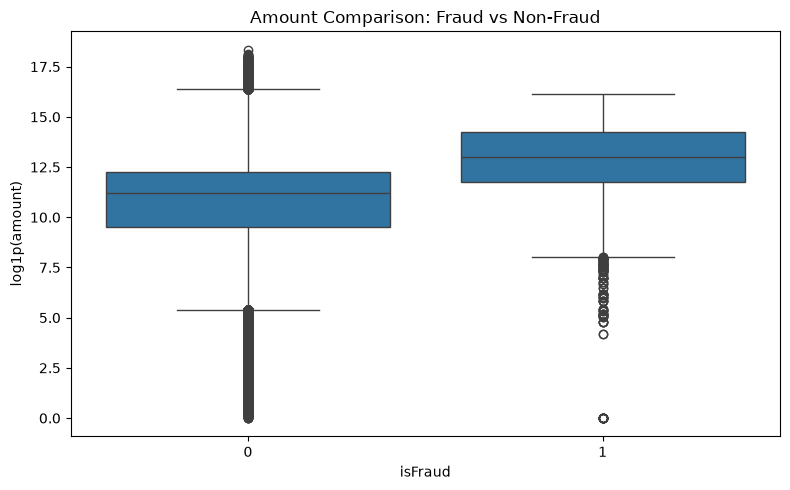

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="isFraud", y=np.log1p(df["amount"]))
plt.title("Amount Comparison: Fraud vs Non-Fraud")
plt.xlabel("isFraud")
plt.ylabel("log1p(amount)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "amount_fraud_vs_nonfraud.png")
plt.show()

In [33]:
fraud_by_step = df.groupby("step")["isFraud"].agg(["count", "sum", "mean"])
fraud_by_step = fraud_by_step.rename(columns={
    "count": "total_transactions",
    "sum": "fraud_transactions",
    "mean": "fraud_rate"
})

fraud_by_step.head()

,total_transactions,fraud_transactions,fraud_rate
step,,,
1,2708,16,0.0059
2,1014,8,0.0079
3,552,4,0.0072
4,565,10,0.0177
5,665,6,0.0090


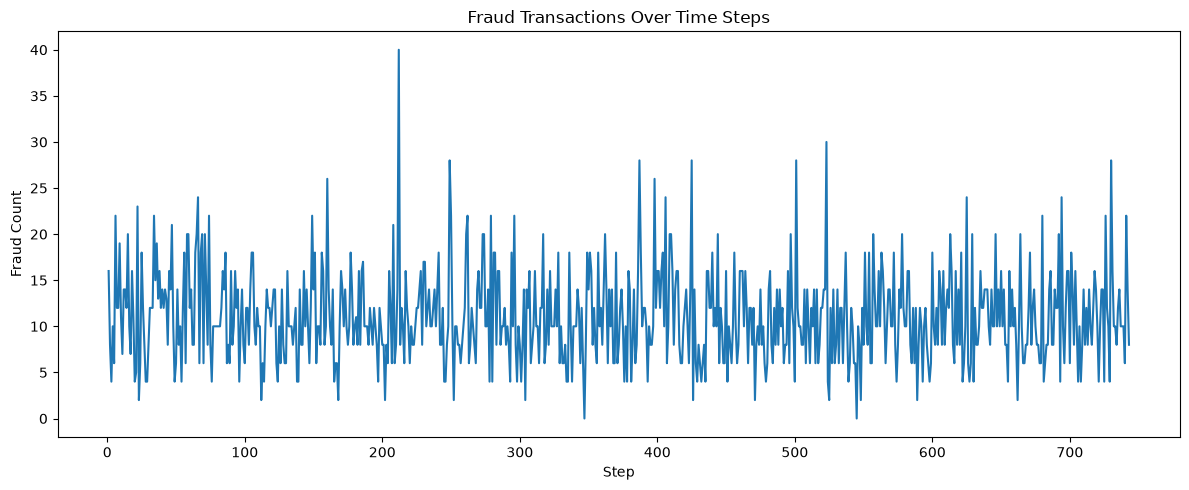

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(fraud_by_step.index, fraud_by_step["fraud_transactions"])
plt.title("Fraud Transactions Over Time Steps")
plt.xlabel("Step")
plt.ylabel("Fraud Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fraud_over_time_steps.png")
plt.show()

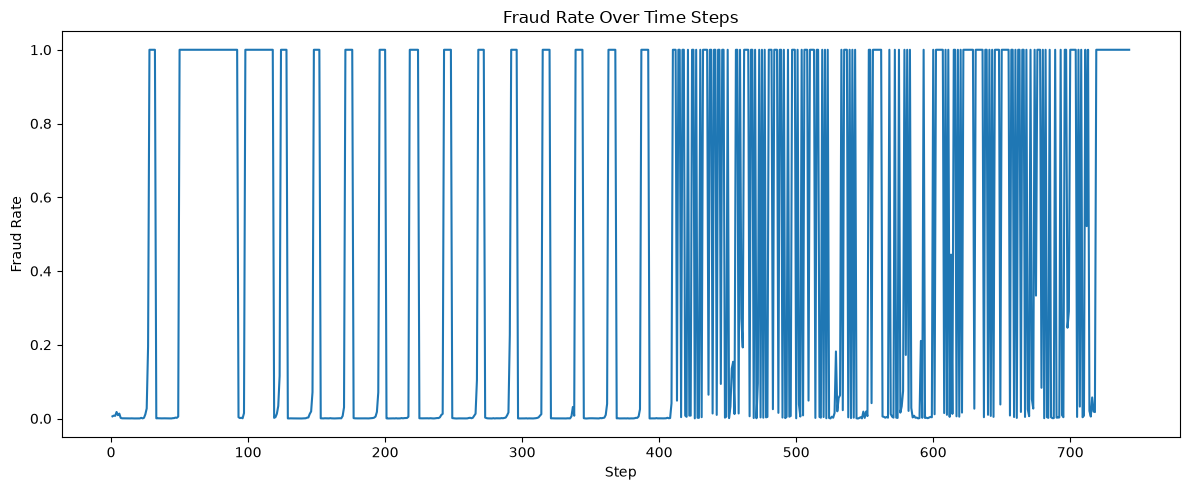

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(fraud_by_step.index, fraud_by_step["fraud_rate"])
plt.title("Fraud Rate Over Time Steps")
plt.xlabel("Step")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fraud_rate_over_time_steps.png")
plt.show()

In [36]:
balance_columns = [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

df[balance_columns].describe()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6362620.0000,6362620.0000,6362620.0000,6362620.0000
mean,833883.1041,855113.6686,1100701.6665,1224996.3982
std,2888242.6730,2924048.5030,3399180.1130,3674128.9421
min,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000
50%,14208.0000,0.0000,132705.6650,214661.4400
75%,107315.1750,144258.4100,943036.7075,1111909.2500
max,59585040.3700,49585040.3700,356015889.3500,356179278.9200


In [37]:
df.groupby("isFraud")[balance_columns].mean()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
isFraud,,,,
0,832828.7117,855970.2281,1101420.8746,1224925.6846
1,1649667.6057,192392.6318,544249.6191,1279707.6171


In [38]:
df_eda = df.copy()

df_eda["orig_balance_error"] = (
    df_eda["oldbalanceOrg"] - df_eda["amount"] - df_eda["newbalanceOrig"]
)

df_eda["dest_balance_error"] = (
    df_eda["oldbalanceDest"] + df_eda["amount"] - df_eda["newbalanceDest"]
)

df_eda[["orig_balance_error", "dest_balance_error"]].describe()

,orig_balance_error,dest_balance_error
count,6362620.0000,6362620.0000
mean,-201092.4681,55567.1719
std,606650.4601,441528.7688
min,-92445516.6400,-75885725.6300
25%,-249641.0875,0.0000
50%,-68677.2550,3500.4900
75%,-2954.2300,29353.0450
max,0.0100,13191233.9800


In [39]:
df_eda.groupby("isFraud")[["orig_balance_error", "dest_balance_error"]].mean()

,orig_balance_error,dest_balance_error
isFraud,,
0,-201338.5581,54692.2317
1,-10692.3253,732509.3011


In [40]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [41]:
pd.crosstab(df["isFraud"], df["isFlaggedFraud"])

isFlaggedFraud,0,1
isFraud,,
0,6354407,0
1,8197,16


In [42]:
flagged_report = pd.crosstab(
    df["isFraud"],
    df["isFlaggedFraud"],
    rownames=["Actual Fraud"],
    colnames=["Flagged Fraud"]
)

flagged_report

Flagged Fraud,0,1
Actual Fraud,,
0,6354407,0
1,8197,16


In [43]:
print("Unique origin accounts:", df["nameOrig"].nunique())
print("Unique destination accounts:", df["nameDest"].nunique())

Unique origin accounts: 6353307
Unique destination accounts: 2722362


In [44]:
df["nameOrig"].value_counts().head(10)

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [45]:
df["nameDest"].value_counts().head(10)

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [46]:
fraud_df = df[df["isFraud"] == 1]

print("Fraud transactions:", fraud_df.shape[0])
print("Unique fraud origin accounts:", fraud_df["nameOrig"].nunique())
print("Unique fraud destination accounts:", fraud_df["nameDest"].nunique())

Fraud transactions: 8213
Unique fraud origin accounts: 8213
Unique fraud destination accounts: 8169


In [47]:
fraud_df["type"].value_counts()

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

In [48]:
fraud_df["amount"].describe()

count       8213.0000
mean     1467967.2991
std      2404252.9472
min            0.0000
25%       127091.3300
50%       441423.4400
75%      1517771.4800
max     10000000.0000
Name: amount, dtype: float64

In [49]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_columns

['step',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

In [50]:
correlation_with_target = df[numeric_columns].corr()["isFraud"].sort_values(ascending=False)
correlation_with_target

isFraud           1.0000
amount            0.0767
isFlaggedFraud    0.0441
step              0.0316
oldbalanceOrg     0.0102
newbalanceDest    0.0005
oldbalanceDest   -0.0059
newbalanceOrig   -0.0081
Name: isFraud, dtype: float64

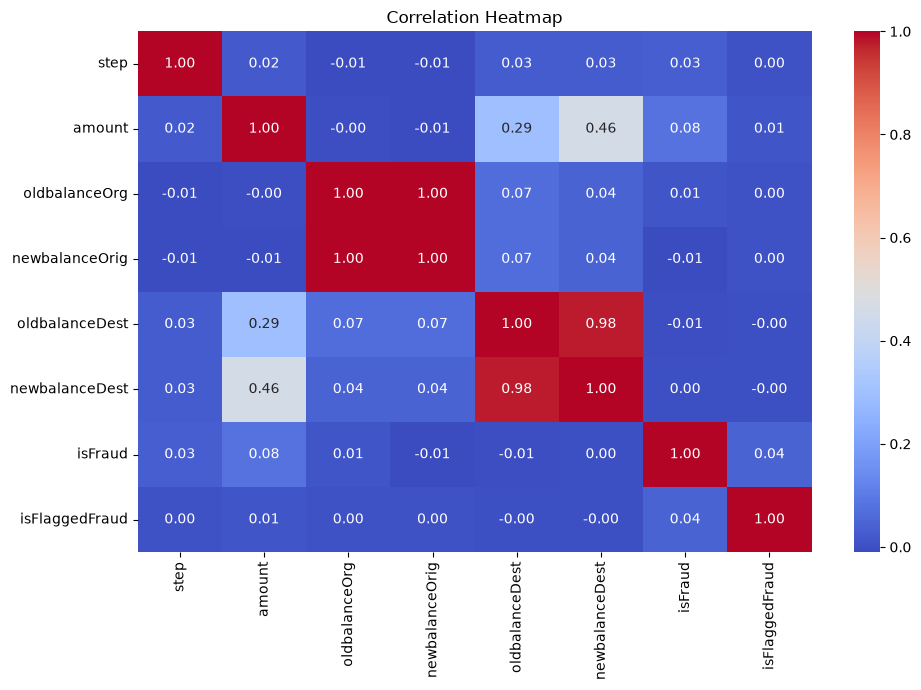

In [51]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png")
plt.show()

In [52]:
eda_summary = {
    "total_rows": df.shape[0],
    "total_columns": df.shape[1],
    "fraud_count": int(fraud_count),
    "non_fraud_count": int(non_fraud_count),
    "fraud_percentage": float((fraud_count / len(df)) * 100),
    "non_fraud_percentage": float((non_fraud_count / len(df)) * 100),
    "imbalance_ratio": float(imbalance_ratio),
    "duplicate_rows": int(duplicate_count),
    "missing_values_total": int(df.isnull().sum().sum()),
    "unique_origin_accounts": int(df["nameOrig"].nunique()),
    "unique_destination_accounts": int(df["nameDest"].nunique()),
}

eda_summary

{'total_rows': 6362620,
 'total_columns': 11,
 'fraud_count': 8213,
 'non_fraud_count': 6354407,
 'fraud_percentage': 0.12908204481801522,
 'non_fraud_percentage': 99.87091795518198,
 'imbalance_ratio': 773.7010836478753,
 'duplicate_rows': 0,
 'missing_values_total': 0,
 'unique_origin_accounts': 6353307,
 'unique_destination_accounts': 2722362}

In [53]:
eda_summary_df = pd.DataFrame([eda_summary])

eda_summary_path = PROJECT_ROOT / "reports" / "eda_summary.csv"
eda_summary_df.to_csv(eda_summary_path, index=False)

eda_summary_df

,total_rows,total_columns,fraud_count,non_fraud_count,fraud_percentage,non_fraud_percentage,imbalance_ratio,duplicate_rows,missing_values_total,unique_origin_accounts,unique_destination_accounts
0,6362620,11,8213,6354407,0.1291,99.8709,773.7011,0,0,6353307,2722362


In [54]:
fraud_by_type_path = PROJECT_ROOT / "reports" / "fraud_by_type.csv"
fraud_by_type.to_csv(fraud_by_type_path)

fraud_by_type

,total_transactions,fraud_transactions,fraud_rate,fraud_rate_percentage
type,,,,
CASH_IN,1399284,0,0.0000,0.0000
CASH_OUT,2237500,4116,0.0018,0.1840
DEBIT,41432,0,0.0000,0.0000
PAYMENT,2151495,0,0.0000,0.0000
TRANSFER,532909,4097,0.0077,0.7688


# EDA Summary

## Main Findings

- The dataset contains transaction-level financial records.
- The target variable is `isFraud`.
- The dataset is highly imbalanced, with fraud transactions forming a very small percentage of total transactions.
- Transaction type has a strong relationship with fraud behavior.
- Transaction amount is highly skewed, so log transformation is useful for visualization and modeling.
- Balance-related fields may be predictive but should be handled carefully to avoid leakage.
- `nameOrig` and `nameDest` are useful identifiers for future graph-based fraud detection.
- Accuracy alone is not suitable for this dataset because of class imbalance.

## Next Step

The next step is data cleaning and preprocessing.